https://medium.com/python-programming-ascendance/my-first-image-generation-gan-network-results-and-python-code-10a0857f09dd

#adaptar a 128x128

In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Flatten, Reshape, Conv2D, Conv2DTranspose, LeakyReLU, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

In [ ]:
import os
os.getcwd()

In [ ]:
def load_images(data_folder):
    image_files = glob.glob(data_folder + '/*.jpg')
    images = []
    for file in image_files:
        image = Image.open(file)
        image = image.resize((64, 64))  # Resize to a manageable size
        image = image.resize((128, 128))  # Resize to a manageable size
        image = np.array(image)
        images.append(image)
    images = np.array(images)
    images = (images - 127.5) / 127.5  # Normalize images to [-1, 1]
    return images




def build_generator():
    model = Sequential()

    # Vector de entrada: ruido de tamaño 100 → 8x8x256
    model.add(Dense(8 * 8 * 256, use_bias=False, input_shape=(100,)))
    model.add(LeakyReLU())
    model.add(Reshape((8, 8, 256)))

    # 8x8x256 → 16x16x128
    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    # 16x16x128 → 32x32x128
    model.add(Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    # 32x32x128 → 64x64x64
    model.add(Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(LeakyReLU())

    # 64x64x64 → 128x128x3
    model.add(Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', 
                              use_bias=False, activation='tanh'))

    return model


def build_discriminator():
    model = Sequential()

    # 128x128x3 → 64x64x64
    model.add(Conv2D(64, (5, 5), strides=(2, 2), padding='same',
                     input_shape=(128, 128, 3)))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # 64x64x64 → 32x32x128
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # 32x32x128 → 16x16x128
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # 16x16x128 → 8x8x128
    model.add(Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(LeakyReLU())
    model.add(Dropout(0.3))

    # Aplanado → salida final
    model.add(Flatten())
    model.add(Dense(1))  # Salida tipo logits (para usar con `from_logits=True`)

    return model




def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)





**Generador**

El generador de una GAN (Generative Adversarial Network) es como un artista imaginario: intenta crear imágenes (o cualquier otro tipo de datos) tan realistas que el discriminador no pueda decir si son falsas o verdaderas.  


Toma un vector de ruido aleatorio (por ejemplo, 100 valores sin sentido) y lo convierte en una imagen estructurada y coherente.  

Aprende a imitar las características visuales del conjunto de datos original.

Cuanto más entrena, más “creativa” y precisa se vuelve al generar resultados difíciles de distinguir de los reales.

* Dense(8*8*256)	(8, 8, 256)	Convierte el vector 1D (de tamaño 100) en una "semilla visual" tridimensional.
* LeakyReLU()	(8, 8, 256)	Agrega no linealidad para que la red pueda aprender formas más complejas.
* Reshape((8, 8, 256))	(8, 8, 256)	Rearma el vector plano en un pequeño volumen tipo imagen inicial.
* Conv2DTranspose(128)	(16, 16, 128)	Primera “escalada” de la imagen usando filtros para crear patrones visuales.
* LeakyReLU()	(16, 16, 128)	Añade activación no lineal.
* Conv2DTranspose(128)	(32, 32, 128)	Segunda escalada: la imagen crece en tamaño y detalles.
* LeakyReLU()	(32, 32, 128)	Mantiene diversidad en los patrones generados.
* Conv2DTranspose(64)	(64, 64, 64)	Tercera escalada: disminuye número de filtros y agranda resolución.
* LeakyReLU()	(64, 64, 64)	Sigue aportando capacidad expresiva.
* Conv2DTranspose(3, tanh)	(128, 128, 3)	Última capa: genera imagen RGB y normaliza píxeles entre -1 y 1 (tanh).  

**Discriminador**  
  
* Conv2D(64) + LeakyReLU	(64×64×64)	Extrae patrones simples (bordes, colores) mientras reduce resolución.  
* Dropout(0.3)	(64×64×64)	Evita que el modelo se sobreentrene; “desactiva” neuronas al azar.
* Conv2D(128) + LeakyReLU	(32×32×128)	Capta estructuras más complejas como formas o texturas.
* Dropout(0.3)	(32×32×128)	Sigue regularizando el aprendizaje.
* Conv2D(128) + LeakyReLU	(16×16×128)	Extrae relaciones espaciales más abstractas.
* Dropout(0.3)	(16×16×128)	Previene que memorice patrones específicos.
* Conv2D(128) + LeakyReLU	(8×8×128)	Último nivel de compresión: sintetiza la imagen en características clave.
* Dropout(0.3)	(8×8×128)	Última barrera contra el sobreajuste.
* Flatten()	(8192,)	Convierte todo a un vector plano para tomar una decisión final.
* Dense(1)	(1,)	Emite un escalar: valor alto = parece real, valor bajo = parece falso. --> al emplear la funcion de persida bin entropy esta espera una salida logit, por ello no se emplea aqui una salida sogmoid

Data set de fachadas de edificios  
https://www.tensorflow.org/tutorials/generative/pix2pix?hl=es-419

In [5]:
data_folder = './images/LZ'
images = load_images(data_folder)

In [6]:
def show_image(img):
    img = (img * 127.5) + 127.5
    img = img.astype(np.uint8)  # Convertir a tipo de datos adecuado para mostrar

    # Mostrar la imagen
    plt.imshow(img)
    plt.axis("off")  # Opcional: oculta los ejes
    plt.show()

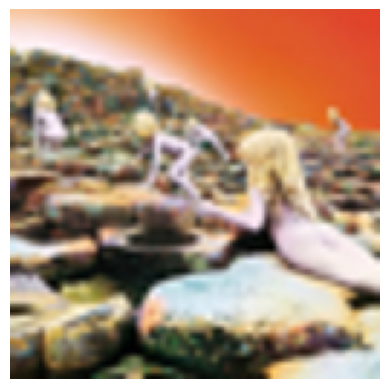

In [7]:
 show_image(images[0])

In [8]:
generator_optimizer = Adam(1e-4)
discriminator_optimizer = Adam(1e-4)
# This method returns a helper function to compute cross entropy loss


In [9]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
generator=build_generator()
discriminator=build_discriminator()

C:\Users\tomas\ML\deep\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\tomas\ML\deep\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
EPOCHS = 500
noise_dim = 100
#num_examples_to_generate = 16
num_examples_to_generate = 16
# We will reuse this seed overtime (so it's easier to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

Buffer es el tamaño de la memoria virtual que TensorFlow usará para mezclar aleatoriamente los datos. Se puede coger un buffer aslgo mayor que el numero de imagenes para asegurarnos de que coge todas las imagenes para la mezcla

In [11]:
BUFFER_SIZE = 10
BATCH_SIZE = 10

In [45]:
# @tf.function #grafo computacional 
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim]) # genera el ruido, crea vectores aleatorios para alimentar al generador.

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))



def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, :] * 0.5 + 0.5)

        plt.axis('off')
        if (epoch%50==0):
          plt.savefig('./images_new/image_at_epoch_{:04d}.png'.format(epoch))
    plt.close()


def upscale_and_save(image_array, scale_factor=4, output_path='output.png'):
    image = Image.fromarray(image_array)
    new_size = (image.width * scale_factor, image.height * scale_factor)
    upscaled = image.resize(new_size, resample=Image.NEAREST)  # o Image.BICUBIC para suavizado
    upscaled.save(output_path)


def generate_and_save_single_image(model, epoch, test_input):
    if epoch % 50 == 0:
        predictions = model(test_input, training=False)

        image = predictions[0]
        image = (image * 127.5 + 127.5).numpy().astype(np.uint8)

        upscale_and_save(image, scale_factor=8, output_path=f'./images_new/image_{epoch:04d}.png')



def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)

        # Produce images for the GIF as we go
        #generate_and_save_images(generator, epoch + 1, seed)
        generate_and_save_single_image(generator, epoch + 1, seed)

        
        # Save the model every epoch

        if epoch % 100 == 0:
            generator.save(f'./generator_epoch_{epoch+1}.h5')
            discriminator.save(f'./discriminator_epoch_{epoch+1}.h5')  # Corregido: antes ponías epoch+51 por error

        
        print(f'Epoch {epoch+1} completed')


**Entrenamiento**  

GradientTape() actua como un grabador. Usa dos "cintas" una para grabar que hace el generador y otra para lo que hace el discrminador.  
El generador intenta crear imágenes realistas a partir del ruido.  
El discriminador debe clasificar cada tipo correctamente.  
El generador quiere que las imágenes falsas parezcan reales (fake_output → 1).  
El discriminador quiere distinguir correctamente (real_output → 1, fake_output → 0).  
Se actualizan los pesos de ambas redes con sus respectivos gradientes.  

In [46]:

# Replace this with your model's filepath
#model_filepath = './generator_epoch_50.h5'

# Load the model
#model = tf.keras.models.load_model(model_filepath)
#model.compile(optimizer='adam',
#              loss='sparse_categorical_crossentropy',
#              metrics=['accuracy'])


# Batch and shuffle the data
train_dataset = tf.data.Dataset.from_tensor_slices(images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [14]:
train_dataset

<_BatchDataset element_spec=TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float64, name=None)>

In [47]:
# Train the model
train(train_dataset, EPOCHS)

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed
Epoch 51 completed
Epoch 52 completed
Epoch 53 completed
Ep

Epoch 101 completed
Epoch 102 completed
Epoch 103 completed
Epoch 104 completed
Epoch 105 completed
Epoch 106 completed
Epoch 107 completed
Epoch 108 completed
Epoch 109 completed
Epoch 110 completed
Epoch 111 completed
Epoch 112 completed
Epoch 113 completed
Epoch 114 completed
Epoch 115 completed
Epoch 116 completed
Epoch 117 completed
Epoch 118 completed
Epoch 119 completed
Epoch 120 completed
Epoch 121 completed
Epoch 122 completed
Epoch 123 completed
Epoch 124 completed
Epoch 125 completed
Epoch 126 completed
Epoch 127 completed
Epoch 128 completed
Epoch 129 completed
Epoch 130 completed
Epoch 131 completed
Epoch 132 completed
Epoch 133 completed
Epoch 134 completed
Epoch 135 completed
Epoch 136 completed
Epoch 137 completed
Epoch 138 completed
Epoch 139 completed
Epoch 140 completed
Epoch 141 completed
Epoch 142 completed
Epoch 143 completed
Epoch 144 completed
Epoch 145 completed
Epoch 146 completed
Epoch 147 completed
Epoch 148 completed
Epoch 149 completed
Epoch 150 completed


Epoch 201 completed
Epoch 202 completed
Epoch 203 completed
Epoch 204 completed
Epoch 205 completed
Epoch 206 completed
Epoch 207 completed
Epoch 208 completed
Epoch 209 completed
Epoch 210 completed
Epoch 211 completed
Epoch 212 completed
Epoch 213 completed
Epoch 214 completed
Epoch 215 completed
Epoch 216 completed
Epoch 217 completed
Epoch 218 completed
Epoch 219 completed
Epoch 220 completed
Epoch 221 completed
Epoch 222 completed
Epoch 223 completed
Epoch 224 completed
Epoch 225 completed
Epoch 226 completed
Epoch 227 completed
Epoch 228 completed
Epoch 229 completed
Epoch 230 completed
Epoch 231 completed
Epoch 232 completed
Epoch 233 completed
Epoch 234 completed
Epoch 235 completed
Epoch 236 completed
Epoch 237 completed
Epoch 238 completed
Epoch 239 completed
Epoch 240 completed
Epoch 241 completed
Epoch 242 completed
Epoch 243 completed
Epoch 244 completed
Epoch 245 completed
Epoch 246 completed
Epoch 247 completed
Epoch 248 completed
Epoch 249 completed
Epoch 250 completed


Epoch 301 completed
Epoch 302 completed
Epoch 303 completed
Epoch 304 completed
Epoch 305 completed
Epoch 306 completed
Epoch 307 completed
Epoch 308 completed
Epoch 309 completed
Epoch 310 completed
Epoch 311 completed
Epoch 312 completed
Epoch 313 completed
Epoch 314 completed
Epoch 315 completed
Epoch 316 completed
Epoch 317 completed
Epoch 318 completed
Epoch 319 completed
Epoch 320 completed
Epoch 321 completed
Epoch 322 completed
Epoch 323 completed
Epoch 324 completed
Epoch 325 completed
Epoch 326 completed
Epoch 327 completed
Epoch 328 completed
Epoch 329 completed
Epoch 330 completed
Epoch 331 completed
Epoch 332 completed
Epoch 333 completed
Epoch 334 completed
Epoch 335 completed
Epoch 336 completed
Epoch 337 completed
Epoch 338 completed
Epoch 339 completed
Epoch 340 completed
Epoch 341 completed
Epoch 342 completed
Epoch 343 completed
Epoch 344 completed
Epoch 345 completed
Epoch 346 completed
Epoch 347 completed
Epoch 348 completed
Epoch 349 completed
Epoch 350 completed


Epoch 401 completed
Epoch 402 completed
Epoch 403 completed
Epoch 404 completed
Epoch 405 completed
Epoch 406 completed
Epoch 407 completed
Epoch 408 completed
Epoch 409 completed
Epoch 410 completed
Epoch 411 completed
Epoch 412 completed
Epoch 413 completed
Epoch 414 completed
Epoch 415 completed
Epoch 416 completed
Epoch 417 completed
Epoch 418 completed
Epoch 419 completed
Epoch 420 completed
Epoch 421 completed
Epoch 422 completed
Epoch 423 completed
Epoch 424 completed
Epoch 425 completed
Epoch 426 completed
Epoch 427 completed
Epoch 428 completed
Epoch 429 completed
Epoch 430 completed
Epoch 431 completed
Epoch 432 completed
Epoch 433 completed
Epoch 434 completed
Epoch 435 completed
Epoch 436 completed
Epoch 437 completed
Epoch 438 completed
Epoch 439 completed
Epoch 440 completed
Epoch 441 completed
Epoch 442 completed
Epoch 443 completed
Epoch 444 completed
Epoch 445 completed
Epoch 446 completed
Epoch 447 completed
Epoch 448 completed
Epoch 449 completed
Epoch 450 completed


Epoch 501 completed
Epoch 502 completed
Epoch 503 completed
Epoch 504 completed
Epoch 505 completed
Epoch 506 completed
Epoch 507 completed
Epoch 508 completed
Epoch 509 completed
Epoch 510 completed
Epoch 511 completed
Epoch 512 completed
Epoch 513 completed
Epoch 514 completed
Epoch 515 completed
Epoch 516 completed
Epoch 517 completed
Epoch 518 completed
Epoch 519 completed
Epoch 520 completed
Epoch 521 completed
Epoch 522 completed
Epoch 523 completed
Epoch 524 completed
Epoch 525 completed
Epoch 526 completed
Epoch 527 completed
Epoch 528 completed
Epoch 529 completed
Epoch 530 completed
Epoch 531 completed
Epoch 532 completed
Epoch 533 completed
Epoch 534 completed
Epoch 535 completed
Epoch 536 completed
Epoch 537 completed
Epoch 538 completed
Epoch 539 completed
Epoch 540 completed
Epoch 541 completed
Epoch 542 completed
Epoch 543 completed
Epoch 544 completed
Epoch 545 completed
Epoch 546 completed
Epoch 547 completed
Epoch 548 completed
Epoch 549 completed
Epoch 550 completed


Epoch 601 completed
Epoch 602 completed
Epoch 603 completed
Epoch 604 completed
Epoch 605 completed
Epoch 606 completed
Epoch 607 completed
Epoch 608 completed
Epoch 609 completed
Epoch 610 completed
Epoch 611 completed
Epoch 612 completed
Epoch 613 completed
Epoch 614 completed
Epoch 615 completed
Epoch 616 completed
Epoch 617 completed
Epoch 618 completed
Epoch 619 completed
Epoch 620 completed
Epoch 621 completed
Epoch 622 completed
Epoch 623 completed
Epoch 624 completed
Epoch 625 completed
Epoch 626 completed
Epoch 627 completed
Epoch 628 completed
Epoch 629 completed
Epoch 630 completed
Epoch 631 completed
Epoch 632 completed
Epoch 633 completed
Epoch 634 completed
Epoch 635 completed
Epoch 636 completed
Epoch 637 completed
Epoch 638 completed
Epoch 639 completed
Epoch 640 completed
Epoch 641 completed
Epoch 642 completed
Epoch 643 completed
Epoch 644 completed
Epoch 645 completed
Epoch 646 completed
Epoch 647 completed
Epoch 648 completed
Epoch 649 completed
Epoch 650 completed


Epoch 701 completed
Epoch 702 completed
Epoch 703 completed
Epoch 704 completed
Epoch 705 completed
Epoch 706 completed
Epoch 707 completed
Epoch 708 completed
Epoch 709 completed
Epoch 710 completed
Epoch 711 completed
Epoch 712 completed
Epoch 713 completed
Epoch 714 completed
Epoch 715 completed
Epoch 716 completed
Epoch 717 completed
Epoch 718 completed
Epoch 719 completed
Epoch 720 completed
Epoch 721 completed
Epoch 722 completed
Epoch 723 completed
Epoch 724 completed
Epoch 725 completed
Epoch 726 completed
Epoch 727 completed
Epoch 728 completed
Epoch 729 completed
Epoch 730 completed
Epoch 731 completed
Epoch 732 completed
Epoch 733 completed
Epoch 734 completed
Epoch 735 completed
Epoch 736 completed
Epoch 737 completed
Epoch 738 completed
Epoch 739 completed
Epoch 740 completed
Epoch 741 completed
Epoch 742 completed
Epoch 743 completed
Epoch 744 completed
Epoch 745 completed
Epoch 746 completed
Epoch 747 completed
Epoch 748 completed
Epoch 749 completed
Epoch 750 completed


KeyboardInterrupt: 

In [49]:
from keras.models import load_model
generador = load_model('generator_epoch_9901.h5')


In [52]:
import numpy as np

tamaño_latente = 100  # ajusta este valor según tu modelo
#ruido = np.random.normal(0, 1, (1, tamaño_latente))
ruido = tf.random.normal([BATCH_SIZE, noise_dim])
imagen_generada = generador.predict(ruido)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


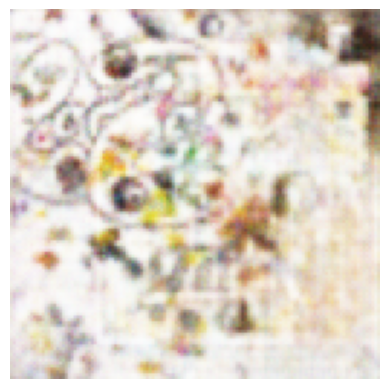

In [53]:
# Si usaste tanh en la capa de salida, reescala a [0,1]
imagen_generada = 0.5 * imagen_generada + 0.5

# Mostrar imagen con matplotlib
plt.imshow(imagen_generada[0])
plt.axis('off')
plt.show()